## Phân tích Tương quan Chính tắc (CCA) với Python

**Bộ dữ liệu Linnerud:** Bao gồm 20 quan sát từ các thành viên câu lạc bộ thể dục. Dữ liệu chia làm hai tập:
* **Tập $X_1$ (Sinh lý):** Cân nặng (Weight), Vòng eo (Waist), Nhịp tim (Pulse).
* **Tập $X_2$ (Thể dục):** Hít xà (Chins), Gập bụng (Situps), Bật nhảy (Jumps).

**Mục tiêu:** Sử dụng thuật toán CCA dựa trên ma trận hiệp phương sai để tìm ra các tổ hợp tuyến tính (biến chính tắc $U$ và $V$) của hai tập dữ liệu sao cho chúng có mức độ tương quan cao nhất.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_linnerud
from scipy.linalg import cholesky, svd, inv

# Tải dữ liệu Linnerud
data = load_linnerud()
X1 = data.data
X2 = data.target

# Mean centering (đưa trung bình về 0 để tính điểm chính tắc chính xác)
X1_centered = X1 - np.mean(X1, axis=0)
X2_centered = X2 - np.mean(X2, axis=0)

## Tính toán Ma trận theo Thuật toán CCA
Thuật toán bao gồm 4 bước:
1. Phân rã Cholesky các ma trận hiệp phương sai nội bộ ($\Sigma_{11}$, $\Sigma_{22}$). Phân rã Cholesky là phép toán ma trận dùng để tách một ma trận đối xứng, xác định dương (như ma trận hiệp phương sai) thành tích của một ma trận tam giác và chuyển vị của nó.
2. Tính ma trận chéo $K$.
3. Phân tích giá trị suy biến (SVD) của $K$ để lấy hệ số tương quan $\rho$.
4. Khôi phục vector trọng số $\mathbf{a}$ và $\mathbf{b}$.

In [ ]:
# Tính ma trận hiệp phương sai
Cov_matrix = np.cov(X1, X2, rowvar=False)
Sigma11 = Cov_matrix[0:3, 0:3]
Sigma22 = Cov_matrix[3:6, 3:6]
Sigma12 = Cov_matrix[0:3, 3:6]

# Bước 1: Cholesky
U1 = cholesky(Sigma11)
U2 = cholesky(Sigma22)

# Bước 2: Ma trận K
inv_U1 = inv(U1)
inv_U2 = inv(U2)
K = inv_U1.T @ Sigma12 @ inv_U2

# Bước 3: SVD
U_hat, Lambda, V_hat_T = svd(K)
V_hat = V_hat_T.T

# Bước 4: Vector trọng số
a = inv_U1 @ U_hat
b = inv_U2 @ V_hat
print (a)
print (b)

[[-0.06611399  0.07104121  0.24527535]
 [-0.01684623 -0.00197375 -0.01976764]
 [ 0.01397157 -0.02071411  0.00816747]]
[[-0.03140469  0.07631951  0.00773505]
 [ 0.49324168 -0.36872299 -0.15803365]
 [-0.00819932  0.03205199 -0.14573224]]


## Ý nghĩa Kết quả
* **Hệ số tương quan ($\rho$):** Nằm trong mảng `Lambda`. Trị số $\rho_1 \approx 0.7956$ cho thấy tồn tại một mối liên hệ tuyến tính rất mạnh giữa các chỉ số sinh lý và khả năng tập thể dục ở cặp biến chính tắc đầu tiên.
* **Vector trọng số ($\mathbf{a}$ và $\mathbf{b}$):** Thể hiện mức độ đóng góp của từng biến gốc vào biến chính tắc. Các biến có trọng số tuyệt đối lớn (như vòng eo trong tập $X_1$ hay gập bụng trong tập $X_2$) đóng vai trò chủ đạo trong việc định hình mối tương quan này.


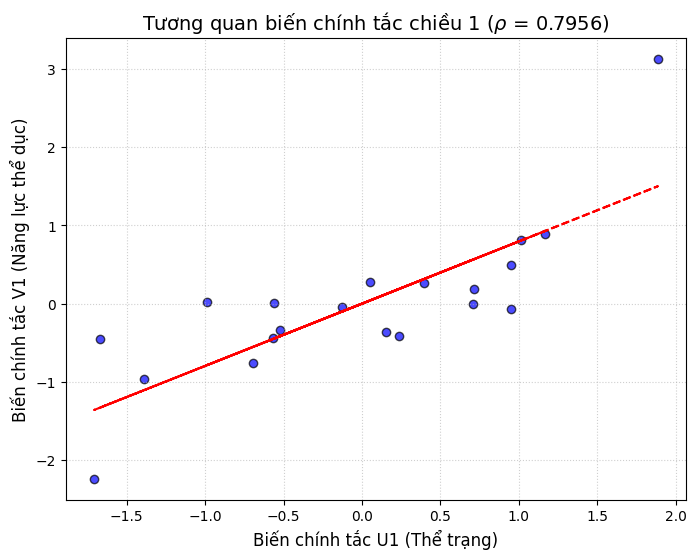

In [ ]:
# Tính điểm biến chính tắc (Canonical Scores)
U = X1_centered @ a
V = X2_centered @ b

# Trích xuất cặp biến chính tắc đầu tiên (Cột 1)
U1_scores = U[:, 0]
V1_scores = V[:, 0]
rho_1 = Lambda[0]

# Vẽ biểu đồ
plt.figure(figsize=(8, 6))
plt.scatter(U1_scores, V1_scores, color='blue', alpha=0.7, edgecolors='k')

# Vẽ đường xu hướng
m, c = np.polyfit(U1_scores, V1_scores, 1)
plt.plot(U1_scores, m * U1_scores + c, color='red', linestyle='--')

plt.title(f'Tương quan biến chính tắc chiều 1 ($\\rho$ = {rho_1:.4f})', fontsize=14)
plt.xlabel('Biến chính tắc U1 (Thể trạng)', fontsize=12)
plt.ylabel('Biến chính tắc V1 (Năng lực thể dục)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()